# Decision Tree Classification: Model Comparison, ROC Curves, and XGBoost
In this notebook, we will walk through building a Decision Tree classifier
using the Breast Cancer Wisconsin (Diagnostic) dataset. Decision trees are non-parametric models that
can capture nonlinear relationships by recursively splitting the data.
____
We'll cover:
1. Loading and inspecting the dataset.
2. Preprocessing: Handling missing values and encoding categorical data.
3. Splitting the data into training and testing sets.
4. Training a Decision Tree model.
5. Evaluating the model's performance with accuracy, confusion matrix, and a classification report.
6. Visualizing the decision tree.
7. Analyzing model performance using ROC curve and AUC.
8. Comparing Decision Tree, Logistic Regression, Random Forest, and XGBoost via ROC curves.

## **Step 1: Load and Inspect the Data**

We use the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle/UCI, which includes features computed from digitized images of fine needle aspirates (FNA) of breast masses. Each row describes characteristics of cell nuclei (e.g., radius, texture, smoothness), and the target variable indicates whether the tumor is **benign (B)** or **malignant (M)**.

In [23]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import kagglehub

# Download the Breast Cancer Wisconsin dataset from Kaggle
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

data = pd.read_csv(f"{path}/data.csv")
data.head()

Path to dataset files: C:\Users\tommy\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### **Step 2: Data Preprocessing**

Our next step is to prepare the data for modeling:

- **Handling Missing Values:**
   The breast cancer dataset is mostly complete, but it contains an unnamed trailing column (`Unnamed: 32`) that is all NaN. We will drop it along with the `id` column, which is not a predictive feature.

- **Encoding Categorical Variables:**
   The `diagnosis` column contains categorical values (`M` for malignant, `B` for benign). We convert this to a numeric format using one-hot encoding.

*Note: We use `drop_first=True` to avoid the dummy variable trap, so `diagnosis_M` = 1 means malignant and 0 means benign.*

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [25]:
data = data.drop(columns=["Unnamed: 32"])


# Handling missing values (optional for decision trees)
data.dropna(inplace=True) # May be needed for logistic regression

# Encode the 'diagnosis' column: M (malignant) -> 1, B (benign) -> 0
df = pd.get_dummies(data, columns=['diagnosis'], drop_first=True) # Use drop_first=True to avoid "dummy trap"


# Define features (X) and target (y)
# Drop non-predictive columns: id, Unnamed: 32 (empty), and the target column
X = df.drop(columns=["id", "diagnosis_M"])
y = df['diagnosis_M']

# Preview the cleaned dataset
print(X.head())
print(y.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

### **Step 3: Splitting the Data**

We split the dataset into training and testing sets. The training set is used to build the decision tree model, while the testing set is used to evaluate its performance.

In [26]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

### **Step 4: Train the Decision Tree Model**

We initialize and train a Decision Tree classifier.
**Why Decision Trees?**
- They are intuitive and easy to interpret.
- They capture non-linear relationships without needing feature scaling.

Here, we use default parameters, but tuning (e.g., max_depth, min_samples_split) can improve performance and prevent overfitting.

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train tree classification model
model = DecisionTreeClassifier(random_state = 42,
                               max_depth = 4) # change default parameters
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### **Step 5: Evaluate the Model**

We now assess our model’s performance on the test data using several metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Confusion Matrix:** Displays the number of correct and incorrect predictions.
- **Classification Report:** Provides precision, recall, and F1-score, which help in understanding performance per class.

Accuracy: 0.95


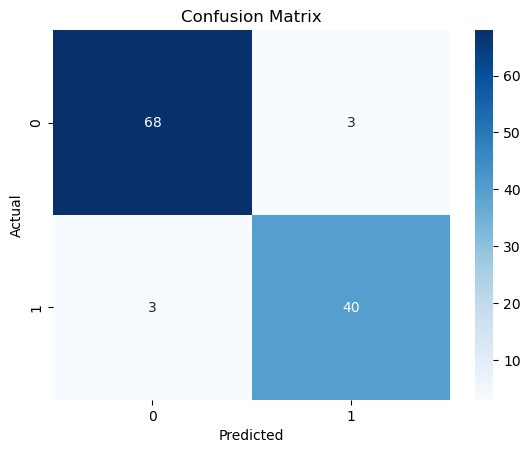

              precision    recall  f1-score   support

       False       0.96      0.96      0.96        71
        True       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

### **Step 6: Visualizing the Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

In [43]:

# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree  # Ensure to import the tree module from sklearn

dot_data = tree.export_graphviz(model, feature_names=X_train.columns,
                                class_names=["Benign", "Malignant"],
                                filled=True)

# Generate and display the decision tree graph
graph = graphviz.Source(dot_data)
graph

CalledProcessError: Command '[WindowsPath('dot'), '-Kdot', '-Tsvg']' returned non-zero exit status 3221225477. [stderr: '']

### **Step 7: ROC Curve and AUC Analysis**
The ROC (Receiver Operating Characteristic) curve helps evaluate the model's
performance across different classification thresholds:

- **ROC Curve:** Plots True Positive Rate (TPR) against False Positive Rate (FPR).
- **AUC (Area Under the Curve):** Summarizes the overall ability of the model to discriminate between classes.

Here, we calculate and plot the ROC curve along with the AUC score.

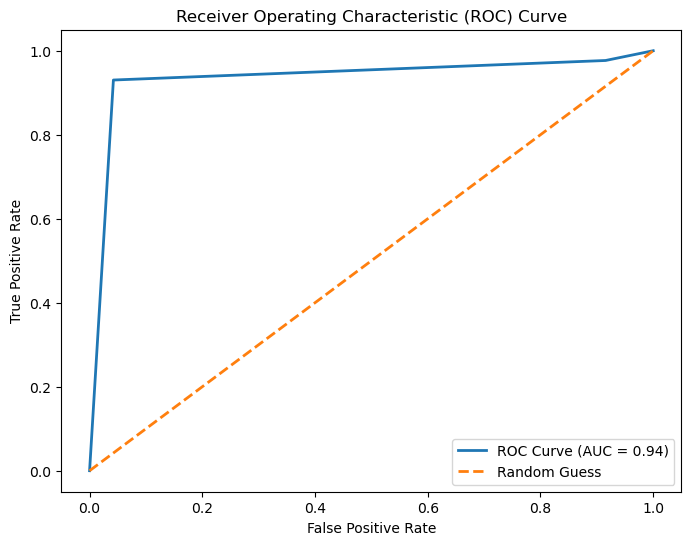

In [37]:
# Import from roc and auc score functions from sklearn
from sklearn.metrics import roc_curve, roc_auc_score

# Get the predicted probabilities for the positive class (malignant)
y_probs = model.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, threshold = roc_curve(y_test, y_probs)

# Compute the Area Under the Curve (AUC) score
roc_auc = roc_auc_score(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})') # Plotting FPR and TPR line
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess') # Plotting 50% line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### **Step 8: Train a Logistic Regression Model**

To compare against our Decision Tree, we now train a Logistic Regression model on the same data. Logistic Regression is a linear model that estimates the probability of a binary outcome, making it a natural baseline for classification tasks like this one.

Accuracy: 0.96


c:\Users\tommy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


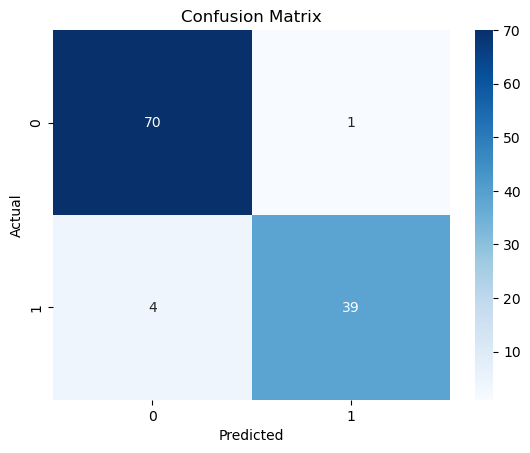

              precision    recall  f1-score   support

       False       0.95      0.99      0.97        71
        True       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize and train logistic regression model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred = lr_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

ROC AUC Score: 1.00


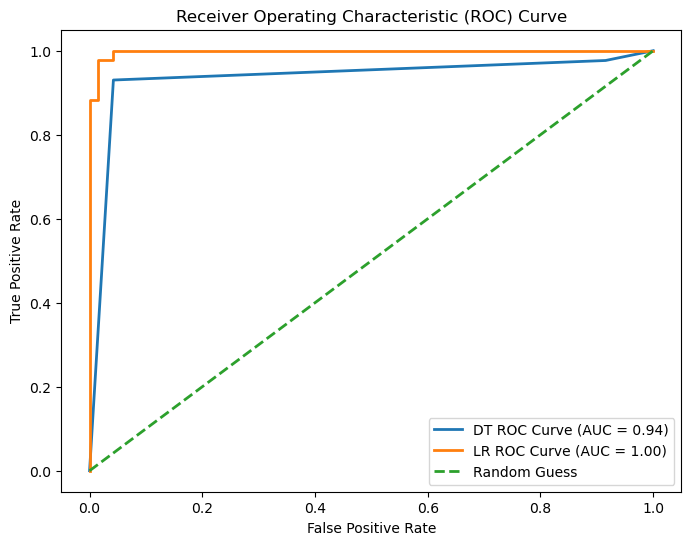

In [32]:
# Get the predicted probabilities for the positive class (malignant)
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_probs_lr)

# Compute the Area Under the Curve (AUC) score
roc_auc_lr = roc_auc_score(y_test, y_probs_lr)
print(f"ROC AUC Score: {roc_auc_lr:.2f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'DT ROC Curve (AUC = {roc_auc:.2f})') # Plot DT FPR/TPR line
plt.plot(fpr_lr, tpr_lr, lw=2, label=f'LR ROC Curve (AUC = {roc_auc_lr:.2f})') # Plot LR FPR/TPR line
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### **Step 9: Train a Random Forest Model**

Random Forest is an ensemble method that builds multiple decision trees on random subsets of the data and averages their predictions. This reduces overfitting compared to a single decision tree and typically improves generalization. We compare its ROC curve against the Decision Tree and Logistic Regression models.

Accuracy: 0.96


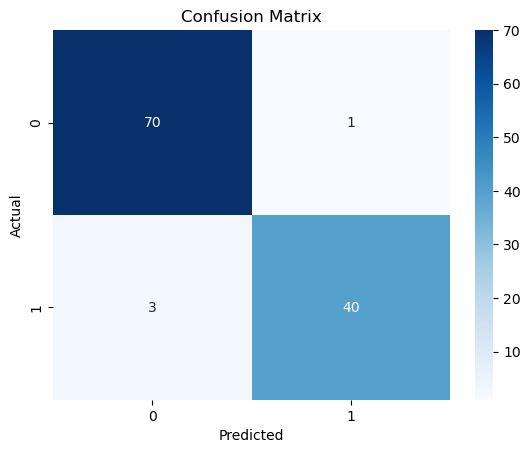

              precision    recall  f1-score   support

       False       0.96      0.99      0.97        71
        True       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [34]:
# Import and fit RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(X_train, y_train)

# Predict on test data
y_pred = random_forest_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

ROC AUC Score: 1.00


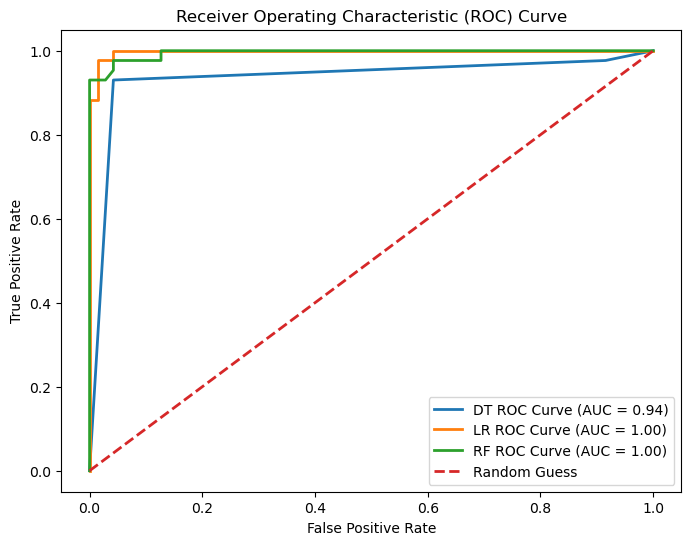

In [35]:
# Get the predicted probabilities for the positive class (malignant)
y_probs_rf = random_forest_classifier.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)

# Compute the Area Under the Curve (AUC) score
roc_auc_rf = roc_auc_score(y_test, y_probs_rf)
print(f"ROC AUC Score: {roc_auc_rf:.2f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'DT ROC Curve (AUC = {roc_auc:.2f})') # Plot DT FPR/TPR line
plt.plot(fpr_lr, tpr_lr, lw=2, label=f'LR ROC Curve (AUC = {roc_auc_lr:.2f})') # Plot LR FPR/TPR line
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RF ROC Curve (AUC = {roc_auc_rf:.2f})') # Plot RF FPR/TPR line
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### **Step 10: Train an XGBoost Model**

XGBoost (Extreme Gradient Boosting) is a powerful ensemble method that builds trees sequentially, where each new tree corrects the errors of the previous ones. It often achieves top performance on structured/tabular data and is widely used in machine learning competitions and industry applications.

Accuracy: 0.96


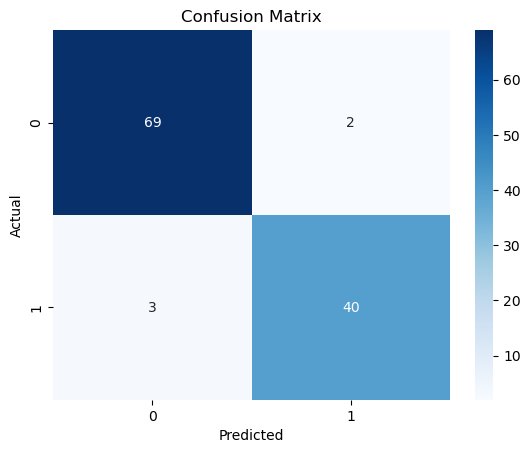

              precision    recall  f1-score   support

       False       0.96      0.97      0.97        71
        True       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [46]:
# Import and fit XGBClassifier
from xgboost import XGBClassifier
xg_model = XGBClassifier()
xg_model.fit(X_train, y_train)

# Predict on test data
y_pred = xg_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

ROC AUC Score: 0.99


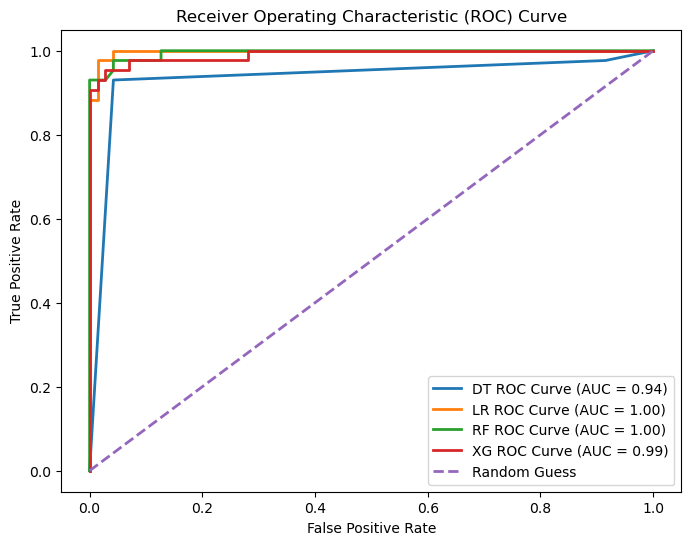

In [47]:
# Get the predicted probabilities for the positive class (malignant)
y_probs_xg = xg_model.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_xg, tpr_xg, thresholds_xg = roc_curve(y_test, y_probs_xg)

# Compute the Area Under the Curve (AUC) score
roc_auc_xg = roc_auc_score(y_test, y_probs_xg)
print(f"ROC AUC Score: {roc_auc_xg:.2f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'DT ROC Curve (AUC = {roc_auc:.2f})') # Plot DT FPR/TPR line
plt.plot(fpr_lr, tpr_lr, lw=2, label=f'LR ROC Curve (AUC = {roc_auc_lr:.2f})') # Plot LR FPR/TPR line
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RF ROC Curve (AUC = {roc_auc_rf:.2f})') # Plot RF FPR/TPR line
plt.plot(fpr_xg, tpr_xg, lw=2, label=f'XG ROC Curve (AUC = {roc_auc_xg:.2f})') # Plot XG FPR/TPR line
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()